In [10]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from pathlib import Path

<h3 style="color: #e19edc;"> Lectura de espectros del 2018</h3>

In [2]:
#Rutas Julio, Agosto y Septiembre

ruta_24_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-24.xlsx"
ruta_27_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-07-27.xlsx"
ruta_03_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-03.xlsx"
ruta_07_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-07.xlsx"
ruta_11_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-11.xlsx"
ruta_16_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-16.xlsx"
ruta_23_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-23.xlsx"
ruta_29_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-08-29.xlsx"
ruta_11_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2018\2018-09-11.xlsx"

In [7]:
#Datos de Julio, Agosto y Septiembre

antares_24_julio = pd.read_excel(ruta_24_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_27_julio = pd.read_excel(ruta_27_julio, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_03_agosto = pd.read_excel(ruta_03_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_07_agosto = pd.read_excel(ruta_07_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_agosto = pd.read_excel(ruta_11_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_16_agosto = pd.read_excel(ruta_16_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_23_agosto = pd.read_excel(ruta_23_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_29_agosto = pd.read_excel(ruta_29_agosto, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])
antares_11_septiembre = pd.read_excel(ruta_11_septiembre, sheet_name = "Sheet1", usecols = [1,2],header = None, names = ["Longitud onda", "Flujo"])

In [9]:
espectros = {
    "antares_24_julio": antares_24_julio,
    "antares_27_julio": antares_27_julio,
    "antares_03_agosto": antares_03_agosto,
    "antares_07_agosto": antares_07_agosto,
    "antares_11_agosto": antares_11_agosto,
    "antares_16_agosto": antares_16_agosto,
    "antares_23_agosto": antares_23_agosto,
    "antares_29_agosto": antares_29_agosto,
    "antares_11_septiembre": antares_11_septiembre,
}

<h4 style="color: #e19edc;"> Parámetros de la normalización con el método Sigma - Clipping</h4>

In [41]:
guardar_graficos = True   
carpeta_graficos = "./Graficas 2018/Espectros_normalizados"  
 
col_longitud_onda = "Longitud onda"
col_flujo = "Flujo"
 
grado_polinomio= 2     
N_iteraciones = 10
sigma_corte = 2.0

<h5 style="color: #e19edc;"> Modelo</h5>

In [48]:
def ajustar_continuo(longitud_onda, flujo, grado, n_iter, sigma):

    longitud_onda = np.asarray(longitud_onda, dtype=float)
    flujo = np.asarray(flujo, dtype=float)
 
    mascara = np.ones_like(flujo, dtype=bool)
 
    for _ in range(n_iter):
        coef = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
        continuo_iter = np.polyval(coef, longitud_onda)
 
        residuo = flujo - continuo_iter
        
        mediana = np.median(residuo[mascara])
        mad = np.median(np.abs(residuo[mascara] - mediana))
        mad_std = mad * 1.4826

        umbral_superior = mediana + sigma * mad_std
        umbral_inferior = mediana - sigma * mad_std
        nueva_mascara = (residuo > umbral_inferior) & (residuo < umbral_superior)
 
        if nueva_mascara.sum() < grado + 2:
            break

        if np.array_equal(nueva_mascara, mascara):
            break
 
        mascara = nueva_mascara
 
    coef_final = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
    continuo = np.polyval(coef_final, longitud_onda)
 
    return continuo, mascara


<h5 style="color: #e19edc;"> Verificación del modelo con gráficos</h5>


Procesando: antares_24_julio
  Puntos totales: 203
  Puntos excluidos: 51
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_24_julio_control.png


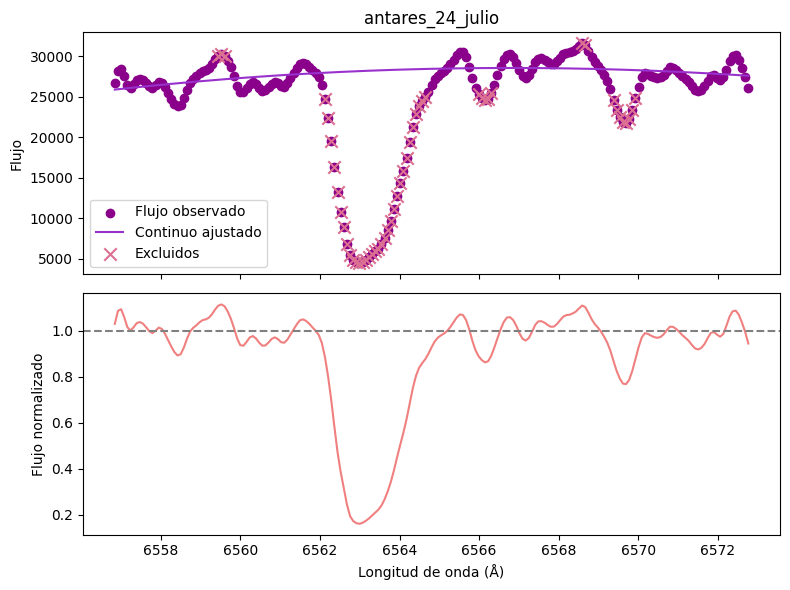


Procesando: antares_27_julio
  Puntos totales: 158
  Puntos excluidos: 68
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_27_julio_control.png


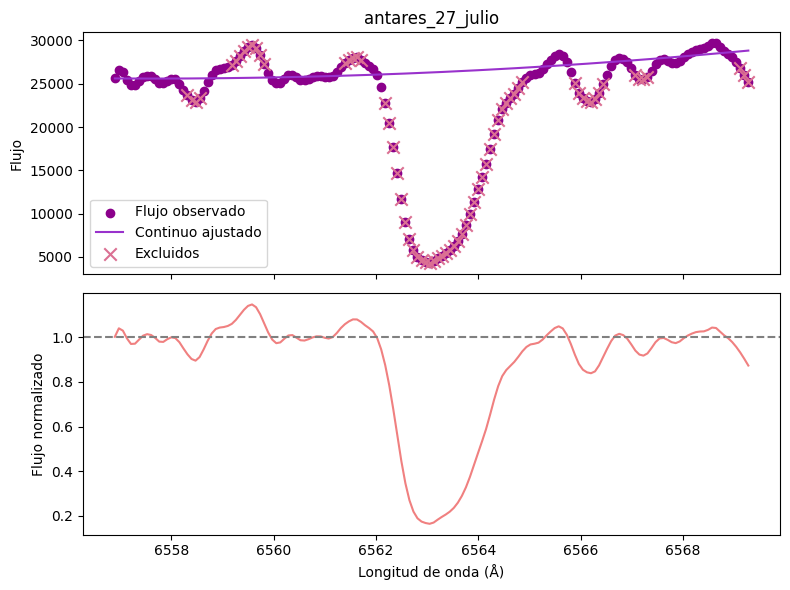


Procesando: antares_03_agosto
  Puntos totales: 161
  Puntos excluidos: 44
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_03_agosto_control.png


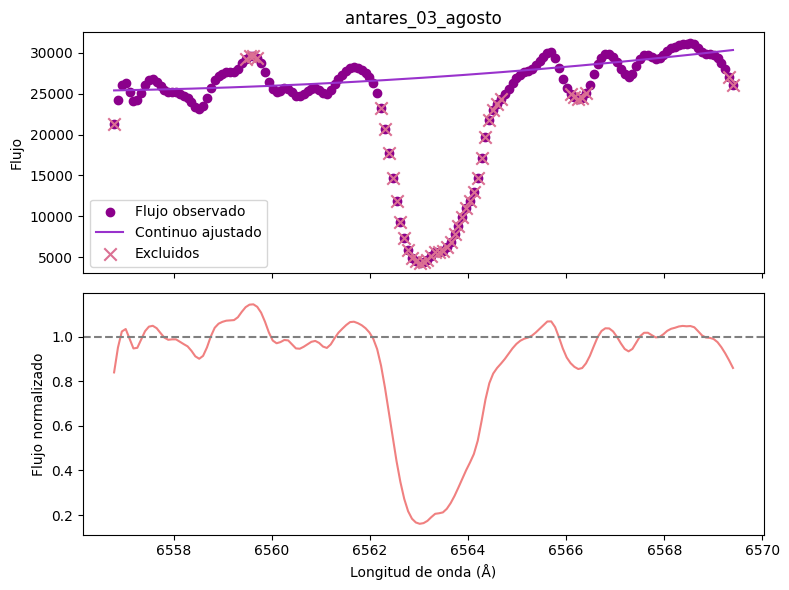


Procesando: antares_07_agosto
  Puntos totales: 162
  Puntos excluidos: 54
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_07_agosto_control.png


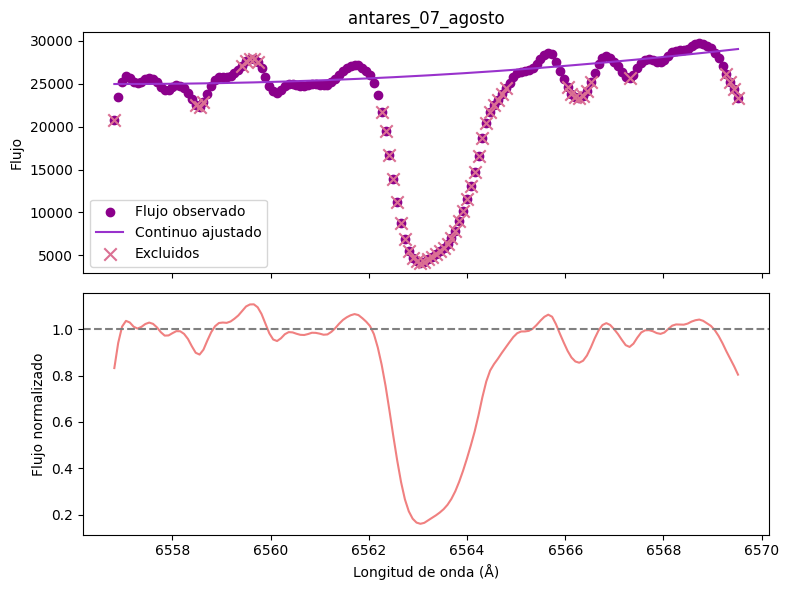


Procesando: antares_11_agosto
  Puntos totales: 163
  Puntos excluidos: 62
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_agosto_control.png


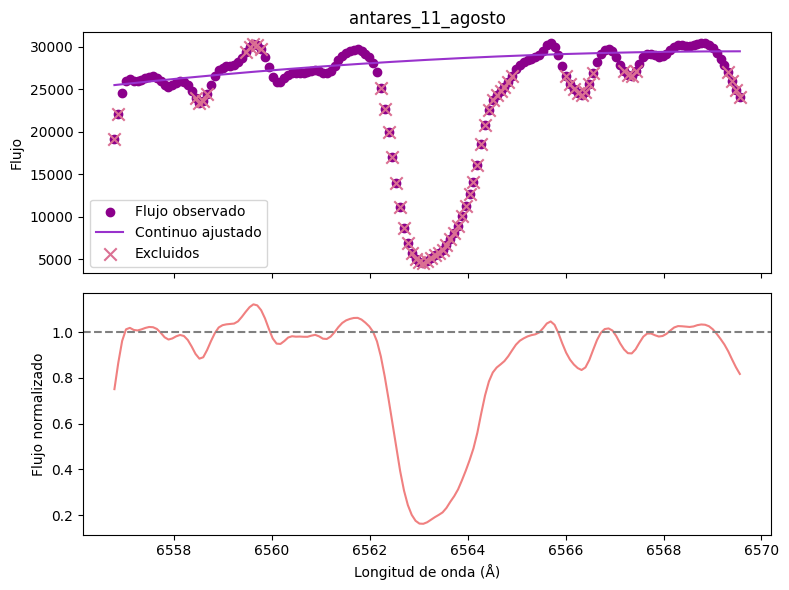


Procesando: antares_16_agosto
  Puntos totales: 163
  Puntos excluidos: 61
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_16_agosto_control.png


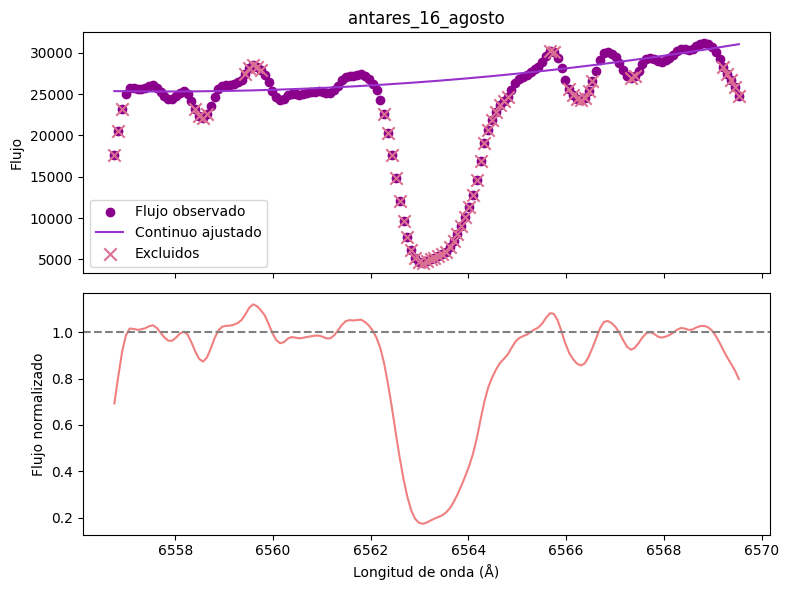


Procesando: antares_23_agosto
  Puntos totales: 162
  Puntos excluidos: 52
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_23_agosto_control.png


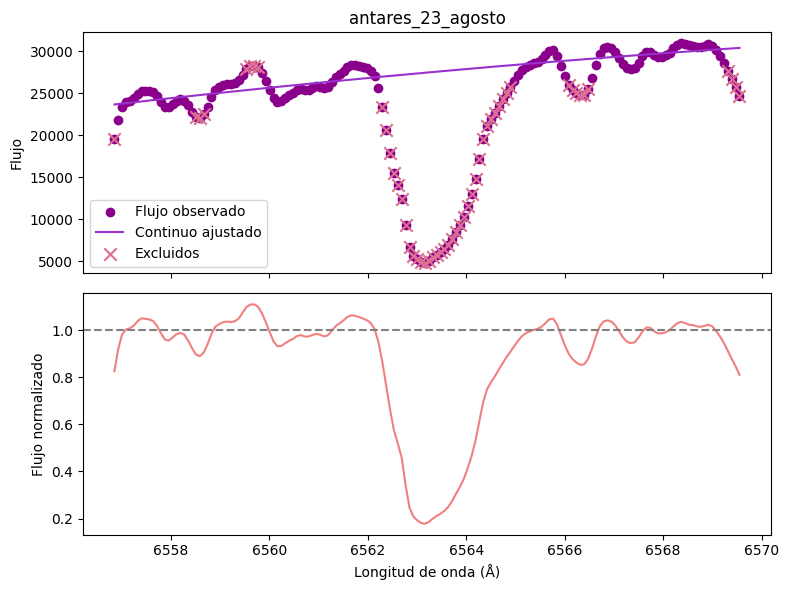


Procesando: antares_29_agosto
  Puntos totales: 206
  Puntos excluidos: 83
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_29_agosto_control.png


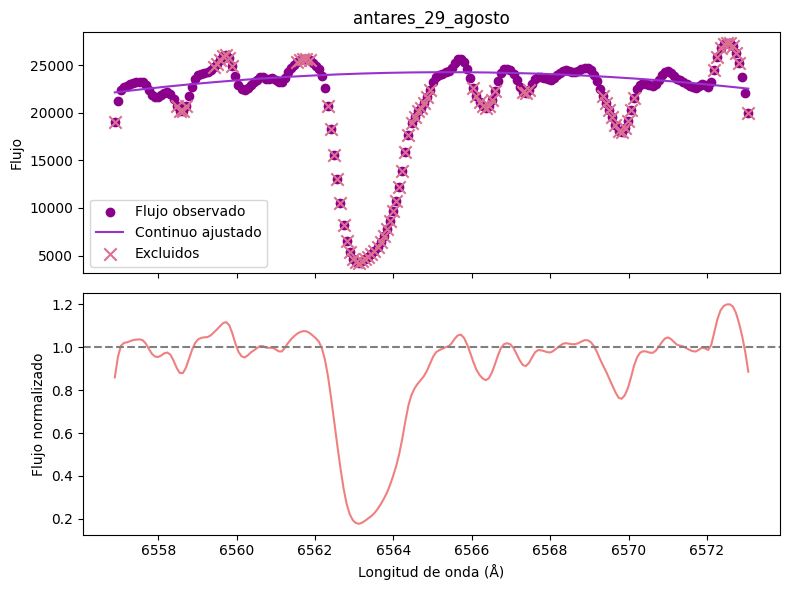


Procesando: antares_11_septiembre
  Puntos totales: 208
  Puntos excluidos: 64
  -> Gráfico guardado: Graficas 2018\Espectros_normalizados\antares_11_septiembre_control.png


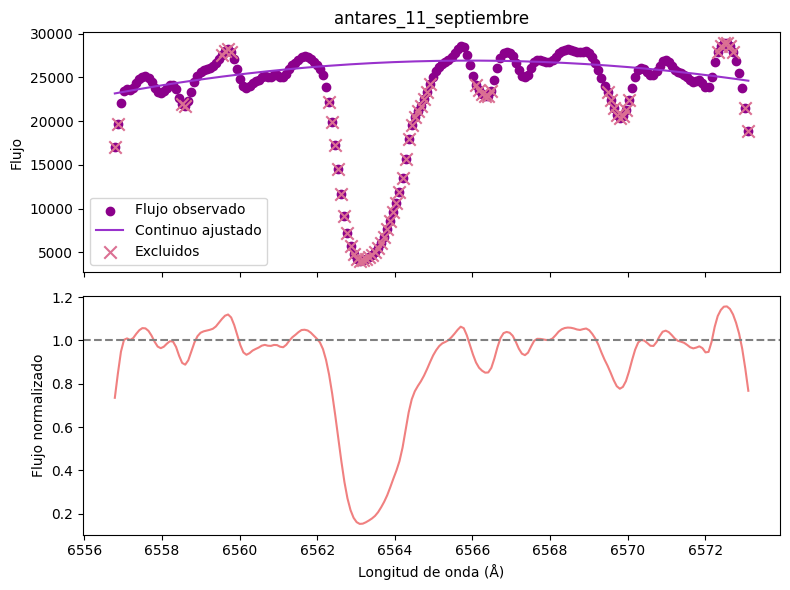


Proceso completo.


In [47]:
if guardar_graficos:
    Path(carpeta_graficos).mkdir(exist_ok=True)
 
for nombre, df in espectros.items():
    print(f"\nProcesando: {nombre}")
 
    longitud_onda = df[col_longitud_onda].values
    flujo = df[col_flujo].values
 
    continuo, mascara_continuo = ajustar_continuo(longitud_onda, flujo, grado_polinomio, N_iteraciones, sigma_corte)

    df["Continuo ajustado"] = continuo
    df["Flujo normalizado"] = flujo / continuo
    df["Usado en ajuste"] = mascara_continuo

    print(f"  Puntos totales: {len(mascara_continuo)}")
    print(f"  Puntos excluidos: {(~mascara_continuo).sum()}")

    mascara_bool = np.asarray(mascara_continuo, dtype=bool)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
 
    ax1.scatter(longitud_onda, flujo, color = "darkmagenta", label="Flujo observado")
    ax1.plot(longitud_onda, continuo, color ="darkorchid", label="Continuo ajustado")
    ax1.scatter(longitud_onda[~mascara_bool], flujo[~mascara_bool], color = "palevioletred",marker = "x", label="Excluidos", s = 80)
    ax1.set_ylabel("Flujo")
    ax1.legend()
    ax1.set_title(nombre)
 
    ax2.plot(longitud_onda, df["Flujo normalizado"], color ="lightcoral")
    ax2.axhline(1.0, color="gray", linestyle="--")
    ax2.set_ylabel("Flujo normalizado")
    ax2.set_xlabel("Longitud de onda (Å)")
 
    plt.tight_layout()
 
    if guardar_graficos:
        fig_path = Path(carpeta_graficos) / f"{nombre}_control.png"
        plt.savefig(fig_path, dpi=120)
        print(f"  -> Gráfico guardado: {fig_path}")
 
    plt.show()
    plt.close(fig)
 
print("\nProceso completo.")